# Description

Here I do the same as the previous notebook, but with the GLS model proposed in PhenoPLIER.

# Modules

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.graphics.gofplots import qqplot_2samples
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import conf
from data.recount2 import LVAnalysis
from phenoplier_plots import qqplot

# Settings

In [2]:
N_PHENOTYPES = 100
N_LVS = 987

In [3]:
INPUT_DIR = (
    conf.RESULTS["GLS_NULL_SIMS"]
    / "twas"
    / "smultixcan"
)
display(INPUT_DIR)
assert INPUT_DIR.exists()

PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan')

In [4]:
OUTPUT_DIR = conf.RESULTS["GLS_NULL_SIMS"]
display(OUTPUT_DIR)

PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims')

In [5]:
PVALUE_COLUMN = "pvalue"

# Load MultiXcan genes present in results

In [6]:
_tmp = pd.read_csv(
    conf.RESULTS["GLS_NULL_SIMS"]
    / "twas"
    / "smultixcan"
    / "random.pheno0-gtex_v8-mashr-smultixcan.txt",
    sep="\t",
)

In [7]:
_tmp.shape

(22519, 18)

In [8]:
_tmp.head()

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status
0,ENSG00000254416.5,RP11-347E10.1,0.000017,4.0,3.0,0.024445,Spleen,0.262916,Nerve_Tibial,2.612788,1.693280e-02,0.340580,-1.311768,2.250056,0.261960,1.758121,3.0,0
1,ENSG00000271564.1,RP13-444H2.1,0.000300,1.0,1.0,0.000300,Testis,0.000300,Testis,1.000000,1.000000e+00,1.000000,-3.615233,-3.615233,-3.615233,NaN,1.0,0
2,ENSG00000181788.3,SIAH2,0.000467,45.0,1.0,0.000042,Muscle_Skeletal,0.017281,Thyroid,43.177415,9.963391e-16,43.177415,-4.094931,3.722543,-1.477930,3.180245,1.0,0
3,ENSG00000168830.7,HTR1E,0.000522,18.0,3.0,0.000067,Thyroid,0.384080,Brain_Hippocampus,9.555565,7.385609e-18,1.151398,-3.780852,3.988471,0.638196,1.955544,3.0,0
4,ENSG00000148734.7,NPFFR1,0.000618,22.0,6.0,0.005663,Brain_Hippocampus,0.973529,Nerve_Tibial,11.780344,6.448113e-18,0.520242,-2.766662,2.766662,-0.709423,1.916941,6.0,0


In [9]:
multixcan_genes = set(_tmp["gene_name"])
display(len(multixcan_genes))
display(list(multixcan_genes)[:10])

22512

['CIRBP',
 'TUBA3C',
 'PKD2L2',
 'AMY2A',
 'CLIP4',
 'INPP5F',
 'ACO1',
 'RP11-140I16.3',
 'RP11-722M1.1',
 'CCNF']

# Load MultiPLIER Z matrix

In [10]:
multiplier_z = pd.read_pickle(conf.MULTIPLIER["MODEL_Z_MATRIX_FILE"])

In [11]:
multiplier_z.shape

(6750, 987)

In [12]:
# keep genes only present in MultiXcan
multiplier_z = multiplier_z.loc[
    sorted(multixcan_genes.intersection(multiplier_z.index))
]

In [13]:
multiplier_z.shape

(6453, 987)

In [14]:
multiplier_z.head()

,LV1,LV2,LV3,LV4,LV5,LV6,LV7,LV8,LV9,LV10,...,LV978,LV979,LV980,LV981,LV982,LV983,LV984,LV985,LV986,LV987
A2M,0.000000,0.000000,0.000000,0.078428,0.0,0.00000,0.000000,0.046772,0.000000,0.011033,...,0.010910,0.000000,0.052869,0.012749,0.0,0.013982,0.152241,0.000000,0.000000,0.108884
AAAS,0.271162,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,1.513337,0.000000,...,0.000000,0.000000,0.000000,0.001385,0.0,0.000000,0.711896,0.030534,0.447105,0.424685
AANAT,0.005099,0.308497,0.028815,0.000000,0.0,0.00000,0.371725,0.000000,0.135238,0.000000,...,0.117163,0.018815,0.000000,0.193142,0.0,0.040401,0.180436,0.000000,0.000000,0.042064
AARS,0.512978,0.000000,0.451285,0.319568,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.006208,0.021274,0.0,0.000000,0.062143,0.000000,0.000000,0.364892
AARS2,1.008157,0.000000,0.197424,0.024832,0.0,0.57081,0.000000,0.228675,0.000000,0.116243,...,0.000000,0.000000,0.153345,0.000000,0.0,0.000000,1.004578,0.014470,0.000000,0.000000


# Functions

In [15]:
def show_prop(data, frac=0.05):
    pvalues = data[PVALUE_COLUMN]
    return get_prop(pvalues, frac=frac)

In [16]:
def get_prop(pvalues, frac=0.05):
    _pvalue_lt_frac = pvalues[pvalues < frac]
    return _pvalue_lt_frac.shape[0] / pvalues.shape[0]

In [17]:
assert get_prop(np.array([0.20, 0.50]), 0.05) == 0.0
assert get_prop(np.array([0.20, 0.50, 0.75, 0.10, 0.04]), 0.05) == 0.2

In [18]:
assert get_prop(pd.Series(np.array([0.20, 0.50])), 0.05) == 0.0
assert get_prop(pd.Series(np.array([0.20, 0.50, 0.75, 0.10, 0.04])), 0.05) == 0.2

In [19]:
def get_lv_genes(lv_code):
    lv_genes = multiplier_z[lv_code].sort_values(ascending=False)
    lv_obj = LVAnalysis(lv_code)
    return lv_obj.lv_genes.set_index("gene_name").loc[lv_genes.index]

# Get files list

In [20]:
INPUT_FILES = list(INPUT_DIR.glob("*.txt"))
display(INPUT_FILES[:5])

[PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan/random.pheno3-gtex_v8-mashr-smultixcan.txt'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan/random.pheno1-gtex_v8-mashr-smultixcan.txt'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan/random.pheno0-gtex_v8-mashr-smultixcan.txt'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan/random.pheno4-gtex_v8-mashr-smultixcan.txt'),
 PosixPath('/home/miltondp/projects/phenoplier/clean_orig_base/phenoplier-gwas-40pcs/results/gls/null_sims/twas/smultixcan/random.pheno2-gtex_v8-mashr-smultixcan.txt')]

# Load data

In [21]:
dfs = [
    pd.read_csv(f, sep="\t").assign(phenotype=f.name.split("-")[0]) for f in INPUT_FILES
]

In [22]:
display(len(dfs))
assert len(dfs) == N_PHENOTYPES

5

AssertionError: 

In [23]:
dfs = pd.concat(dfs, axis=0, ignore_index=True)

In [24]:
display(dfs.shape)
assert dfs.shape[0] == N_PHENOTYPES * N_LVS

(112595, 19)

AssertionError: 

In [25]:
dfs.head()

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status,phenotype
0,ENSG00000144026.11,ZNF514,0.000137,49.0,3.0,0.000013,Brain_Cerebellar_Hemisphere,0.631489,Kidney_Cortex,38.079559,3.746315e-15,2.202802,-4.356392,0.479632,-2.935305,0.857303,3.0,0,random.pheno3
1,ENSG00000159640.15,ACE,0.000216,46.0,2.0,0.000015,Nerve_Tibial,0.009290,Muscle_Skeletal,42.738613,1.944214e-15,2.210563,-4.336018,4.100796,-2.195570,3.338305,2.0,0,random.pheno3
2,ENSG00000130287.13,NCAN,0.000255,3.0,3.0,0.000811,Brain_Putamen_basal_ganglia,0.092559,Brain_Cerebellar_Hemisphere,1.393594,6.120236e-01,0.612024,-3.348974,2.530532,-0.833497,3.030211,3.0,0,random.pheno3
3,ENSG00000174332.5,GLIS1,0.000465,42.0,2.0,0.000055,Nerve_Tibial,0.859347,Cells_Cultured_fibroblasts,36.873740,3.638567e-15,3.269893,-4.032955,0.177206,-3.504855,0.777664,2.0,0,random.pheno3
4,ENSG00000177614.10,PGBD5,0.000657,46.0,6.0,0.000672,Thyroid,0.989194,Artery_Tibial,23.622371,1.614467e-15,1.004145,-3.400598,3.252881,0.143564,1.141656,6.0,0,random.pheno3


In [26]:
_tmp = dfs.groupby("phenotype")["gene"].nunique().unique()
assert _tmp.shape[0] == 1
assert _tmp[0] == N_LVS

AssertionError: 

# Mean type I error

In [27]:
_mt1e = show_prop(dfs)
display(_mt1e)

0.04533060970735823

# QQ-plot

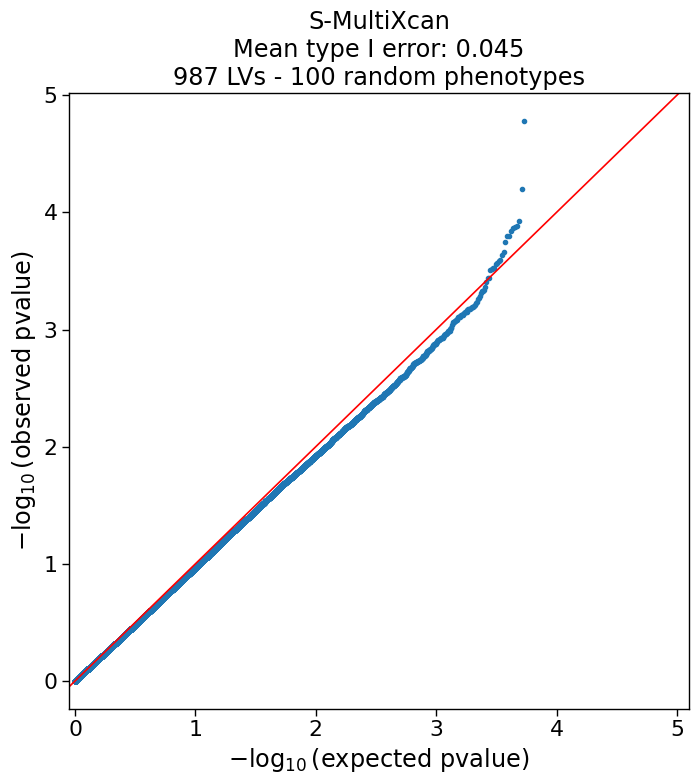

In [28]:
with sns.plotting_context("paper", font_scale=1.8), mpl.rc_context(
    {"lines.markersize": 3}
):
    fig, ax = qqplot(dfs[PVALUE_COLUMN])
    ax.set_title(
        f"S-MultiXcan\nMean type I error: {_mt1e:.3f}\n{N_LVS} LVs - {N_PHENOTYPES} random phenotypes"
    )

In [29]:
dfs.sort_values("pvalue")

,gene,gene_name,pvalue,n,n_indep,p_i_best,t_i_best,p_i_worst,t_i_worst,eigen_max,eigen_min,eigen_min_kept,z_min,z_max,z_mean,z_sd,tmi,status,phenotype
45038,ENSG00000254416.5,RP11-347E10.1,0.000017,4.0,3.0,0.024445,Spleen,0.262916,Nerve_Tibial,2.612788,1.693280e-02,0.340580,-1.311768,2.250056,0.261960,1.758121,3.0,0,random.pheno0
22519,ENSG00000004399.12,PLXND1,0.000063,29.0,6.0,0.000154,Nerve_Tibial,0.913969,Minor_Salivary_Gland,16.746498,3.818086e-16,0.900608,-3.092967,3.784333,0.929625,1.869188,6.0,0,random.pheno1
67557,ENSG00000115561.15,CHMP3,0.000117,49.0,3.0,0.000081,Brain_Cerebellar_Hemisphere,0.919194,Cells_EBV-transformed_lymphocytes,41.676186,1.114471e-15,2.860603,-3.941313,3.561598,1.072601,1.360405,3.0,0,random.pheno4
67558,ENSG00000239305.6,RNF103,0.000132,39.0,4.0,0.000025,Brain_Hippocampus,0.855968,Brain_Amygdala,22.983558,5.308586e-16,0.968103,-4.210815,1.243871,-2.379651,1.998817,4.0,0,random.pheno4
67559,ENSG00000271945.1,RP11-354K4.2,0.000133,11.0,4.0,0.000005,Brain_Hypothalamus,0.337592,Kidney_Cortex,7.687786,6.759777e-17,0.520922,0.958933,4.576179,2.136489,0.947789,4.0,0,random.pheno4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90075,ENSG00000242019.1,KIR3DL3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,random.pheno4
112591,ENSG00000135925.8,WNT10A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,random.pheno2
112592,ENSG00000253182.1,RP11-486M23.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,random.pheno2
112593,ENSG00000236463.1,LINC00427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,random.pheno2


# Summary of mean type I error per LV

In [ ]:
summary_list = []
for lv, lv_data in dfs.groupby("gene"):
    # assert lv_data.shape[0] == N_PHENOTYPES

    summary_list.append(
        {
            "lv": lv,
            "1": get_prop(lv_data[PVALUE_COLUMN], 0.01),
            "5": get_prop(lv_data[PVALUE_COLUMN], 0.05),
            "10": get_prop(lv_data[PVALUE_COLUMN], 0.10),
        }
    )

summary_df = pd.DataFrame(summary_list)
# assert summary_df.shape[0] == N_LVS

In [31]:
summary_df.shape

NameError: name 'summary_df' is not defined

In [35]:
summary_df.head()

,lv,1,5,10
0,ENSG00000000419.12,0.01,0.08,0.10
1,ENSG00000000457.13,0.03,0.05,0.08
2,ENSG00000000460.16,0.00,0.03,0.08
3,ENSG00000000938.12,0.01,0.02,0.05
4,ENSG00000000971.15,0.00,0.04,0.08


In [36]:
summary_df.describe()

,1,5,10
count,21863.000000,21863.000000,21863.000000
mean,0.010280,0.050167,0.099921
std,0.010253,0.022531,0.030948
min,0.000000,0.000000,0.000000
25%,0.000000,0.030000,0.080000
50%,0.010000,0.050000,0.100000
75%,0.020000,0.060000,0.120000
max,0.170000,0.300000,0.390000


## LVs with expected type I error

In [37]:
lvs_expected_error = summary_df[summary_df["5"].between(0.049, 0.051)]
display(lvs_expected_error.shape)
display(lvs_expected_error.sort_values("5").head(20))
display(lvs_expected_error.sort_values("5").tail(20))

(3809, 4)

,lv,1,5,10
1,ENSG00000000457.13,0.03,0.05,0.08
14546,ENSG00000187479.5,0.01,0.05,0.13
14547,ENSG00000187486.5,0.01,0.05,0.09
14549,ENSG00000187498.14,0.02,0.05,0.07
14550,ENSG00000187510.8,0.02,0.05,0.07
14556,ENSG00000187533.13,0.01,0.05,0.06
14573,ENSG00000187609.15,0.00,0.05,0.12
14575,ENSG00000187624.8,0.01,0.05,0.11
14576,ENSG00000187626.8,0.01,0.05,0.08
14581,ENSG00000187650.3,0.00,0.05,0.10


,lv,1,5,10
7172,ENSG00000138834.12,0.03,0.05,0.10
7182,ENSG00000139083.10,0.03,0.05,0.09
7194,ENSG00000139160.13,0.01,0.05,0.09
7195,ENSG00000139163.15,0.01,0.05,0.07
7292,ENSG00000139734.17,0.01,0.05,0.09
7202,ENSG00000139187.9,0.02,0.05,0.12
7222,ENSG00000139291.13,0.01,0.05,0.09
7226,ENSG00000139323.13,0.01,0.05,0.07
7232,ENSG00000139350.11,0.01,0.05,0.10
7234,ENSG00000139352.3,0.01,0.05,0.10


## LVs with high type I error

In [41]:
lvs_high_error = summary_df[summary_df["5"] > 0.07]
display(lvs_high_error.shape)
# display(lvs_high_error.sort_values("5").head(20))
display(lvs_high_error.sort_values("5").tail(20))

(2923, 4)

,lv,1,5,10
2089,ENSG00000100304.12,0.04,0.14,0.17
19455,ENSG00000257510.1,0.02,0.14,0.16
8432,ENSG00000148516.21,0.01,0.14,0.17
20120,ENSG00000261598.1,0.02,0.14,0.21
11283,ENSG00000167779.7,0.04,0.14,0.18
1757,ENSG00000090989.17,0.03,0.14,0.17
8210,ENSG00000146197.8,0.03,0.14,0.19
3716,ENSG00000112273.6,0.02,0.14,0.20
4950,ENSG00000122852.14,0.01,0.14,0.22
4008,ENSG00000114812.12,0.06,0.14,0.19


## Save

In [39]:
lvs_high_error.to_pickle("/tmp/no_genes.pkl")